<h2>Setup and Data Check</h2>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/cmu/idl/final_project/idl_project2/baseline_lstm
!ls

Mounted at /content/drive
/content/drive/MyDrive/cmu/idl/final_project/idl_project2/baseline_lstm
eda.py			  sensor_trend_unit1.png
evaluate.py		  summary.md
evaluation_results.png	  test_preprocessed.csv
lstm2.ipynb		  test_preprocessed_FD001.csv
lstm_model_FD001.pth	  test_preprocessed_FD002.csv
lstm_model_FD002.pth	  test_preprocessed_FD003.csv
lstm_model_FD003.pth	  test_preprocessed_FD004.csv
lstm_model_FD004.pth	  training_loss.png
lstm_model.pth		  train_preprocessed.csv
lstm_multi.ipynb	  train_preprocessed_FD001.csv
lstm_multi_v2.ipynb	  train_preprocessed_FD002.csv
model.py		  train_preprocessed_FD003.csv
preprocessing.py	  train_preprocessed_FD004.csv
processed_test_data.csv   train.py
processed_train_data.csv


<h2>preprocessing.py</h2>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os
import argparse

# Define the data path relative to the workspace
data_path = '../6.+Turbofan+Engine+Degradation+Simulation+Data+Set/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData'

col_names = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]

def load_data(file_name):
    file_path = os.path.join(data_path, file_name)
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Data file not found: {file_path}")
    df = pd.read_csv(file_path, sep='\\s+', header=None, names=col_names)
    return df

def calculate_train_rul(df):
    max_cycle = df.groupby('unit')['cycle'].max().reset_index()
    max_cycle.columns = ['unit', 'max_cycle']
    df = df.merge(max_cycle, on=['unit'], how='left')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df.drop('max_cycle', axis=1, inplace=True)
    return df

def calculate_test_rul(test_df, rul_truth_file):
    rul_truth = pd.read_csv(os.path.join(data_path, rul_truth_file), sep='\\s+', header=None, names=['true_rul'])
    rul_truth['unit'] = rul_truth.index + 1
    test_max_cycle = test_df.groupby('unit')['cycle'].max().reset_index()
    test_max_cycle.columns = ['unit', 'max_cycle']
    test_df = test_df.merge(test_max_cycle, on=['unit'], how='left')
    test_df = test_df.merge(rul_truth, on=['unit'], how='left')
    test_df['RUL'] = test_df['true_rul'] + (test_df['max_cycle'] - test_df['cycle'])
    test_df.drop(['max_cycle', 'true_rul'], axis=1, inplace=True)
    return test_df

def run_preprocessing(dataset_id='FD001'):
    print(f"\n--- Starting Preprocessing for {dataset_id} ---")
    train_df = load_data(f'train_{dataset_id}.txt')
    test_df = load_data(f'test_{dataset_id}.txt')
    train_df = calculate_train_rul(train_df)
    test_df = calculate_test_rul(test_df, f'RUL_{dataset_id}.txt')

    CLIP_LIMIT = 125
    train_df['RUL'] = train_df['RUL'].clip(upper=CLIP_LIMIT)
    test_df['RUL'] = test_df['RUL'].clip(upper=CLIP_LIMIT)

    constant_sensors = []
    potential_cols = [col for col in train_df.columns if col.startswith('s') or col.startswith('os')]
    for col in potential_cols:
        if train_df[col].min() == train_df[col].max():
            constant_sensors.append(col)

    train_df.drop(columns=constant_sensors, inplace=True)
    test_df.drop(columns=constant_sensors, inplace=True)

    cols_to_normalize = train_df.columns.difference(['unit', 'RUL'])
    scaler = MinMaxScaler()
    scaler.fit(train_df[cols_to_normalize])
    train_df[cols_to_normalize] = scaler.transform(train_df[cols_to_normalize])
    test_df[cols_to_normalize] = scaler.transform(test_df[cols_to_normalize])

    train_df.to_csv(f'train_preprocessed_{dataset_id}.csv', index=False)
    test_df.to_csv(f'test_preprocessed_{dataset_id}.csv', index=False)
    print(f"SUCCESS! {dataset_id} is ready.")

for ds in ['FD001', 'FD002', 'FD003', 'FD004']:
    run_preprocessing(ds)


--- Starting Preprocessing for FD001 ---
SUCCESS! FD001 is ready.

--- Starting Preprocessing for FD002 ---
SUCCESS! FD002 is ready.

--- Starting Preprocessing for FD003 ---
SUCCESS! FD003 is ready.

--- Starting Preprocessing for FD004 ---
SUCCESS! FD004 is ready.


<h2>model.py</h2>

In [ ]:
import torch
import torch.nn as nn
import numpy as np

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super(LSTMModel, self).__init__()
        # Standard Unidirectional LSTM
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        # Take the last time step
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out

def create_sequences(data, window_size):
    sequences = []
    labels = []
    for unit in data['unit'].unique():
        unit_data = data[data['unit'] == unit]
        features = unit_data.drop(columns=['unit', 'RUL']).values
        target = unit_data['RUL'].values
        for i in range(len(unit_data) - window_size + 1):
            window = features[i : i + window_size]
            label = target[i + window_size - 1]
            sequences.append(window)
            labels.append(label)
    return np.array(sequences), np.array(labels)


def create_last_sequences(data, window_size):
    """
    Returns only the LAST sliding window per engine unit.
    This matches the standard C-MAPSS evaluation protocol used by the DCNN:
    predict RUL only at the final observed cycle before engine failure.
    """
    sequences = []
    labels = []
    for unit in data['unit'].unique():
        unit_data = data[data['unit'] == unit]
        features = unit_data.drop(columns=['unit', 'RUL']).values
        target = unit_data['RUL'].values
        if len(unit_data) >= window_size:
            # Only the last window — mirrors the DCNN's test evaluation
            sequences.append(features[-window_size:])
            labels.append(target[-1])
    return np.array(sequences), np.array(labels)

<h2>train.py</h2>


Training FD001 on cuda...
Epoch [1/50], Loss: 5228.1023
Epoch [10/50], Loss: 1760.4187
Epoch [20/50], Loss: 1759.3763
Epoch [30/50], Loss: 186.6440
Epoch [40/50], Loss: 168.0871
Epoch [50/50], Loss: 160.8002

Evaluating on Test Set...
------------------------------
Final Test RMSE:  13.4068
------------------------------


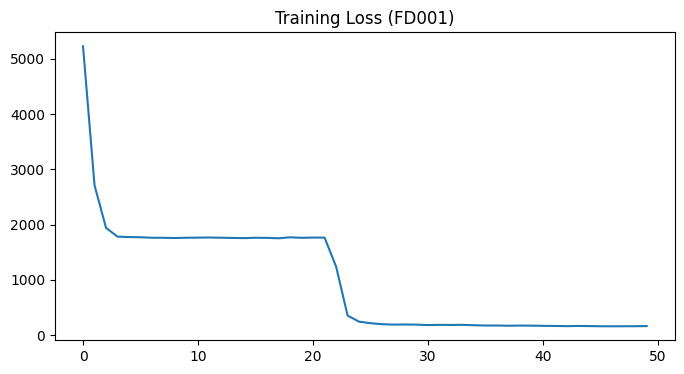


Training FD002 on cuda...
Epoch [1/50], Loss: 3585.4192
Epoch [10/50], Loss: 1762.2655
Epoch [20/50], Loss: 425.7182
Epoch [30/50], Loss: 267.0707
Epoch [40/50], Loss: 108.5860
Epoch [50/50], Loss: 62.3681

Evaluating on Test Set...
------------------------------
Final Test RMSE:  20.8068
------------------------------


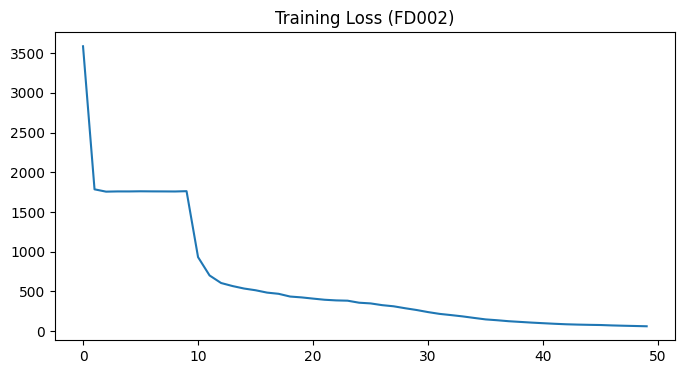


Training FD003 on cuda...
Epoch [1/50], Loss: 5854.3943
Epoch [10/50], Loss: 1734.0385
Epoch [20/50], Loss: 214.4626
Epoch [30/50], Loss: 148.5847
Epoch [40/50], Loss: 127.5803
Epoch [50/50], Loss: 106.9658

Evaluating on Test Set...
------------------------------
Final Test RMSE:  12.3088
------------------------------


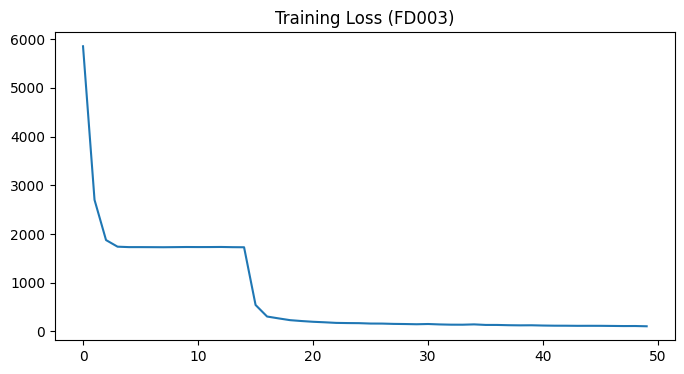


Training FD004 on cuda...
Epoch [1/50], Loss: 3825.8006
Epoch [10/50], Loss: 643.9257
Epoch [20/50], Loss: 273.1948
Epoch [30/50], Loss: 90.0194
Epoch [40/50], Loss: 48.5391
Epoch [50/50], Loss: 41.9392

Evaluating on Test Set...
------------------------------
Final Test RMSE:  24.6357
------------------------------


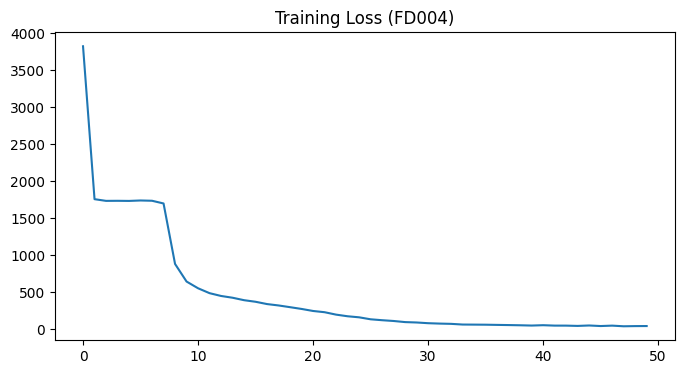

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

def train_model(dataset_id='FD001', window_size=30, batch_size=64, hidden_size=128, num_layers=2, learning_rate=0.001, epochs=50):
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nTraining {dataset_id} on {DEVICE}...")

    train_df = pd.read_csv(f'train_preprocessed_{dataset_id}.csv')
    X_train, y_train = create_sequences(train_df, window_size)

    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

    input_size = X_train.shape[2]
    model = LSTMModel(input_size, hidden_size, num_layers).to(DEVICE)
    # Standard MSE Loss
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = []
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        history.append(avg_loss)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    print("\nEvaluating on Test Set...")
    model.eval()
    test_df = pd.read_csv(f'test_preprocessed_{dataset_id}.csv')
    # BEFORE (evaluates ALL sliding windows — inflates LSTM's RMSE advantage)
    # X_test, y_test = create_sequences(test_df, window_size)
    # AFTER (evaluates only LAST window per engine — matches DCNN protocol)
    X_test, y_test = create_last_sequences(test_df, window_size)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

    test_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            test_loss += loss.item() * batch_X.size(0)

    test_rmse = np.sqrt(test_loss / len(test_loader.dataset))
    print("-" * 30)
    print(f"Final Test RMSE:  {test_rmse:.4f}")
    print("-" * 30)
    torch.save({
        'model_state_dict': model.state_dict(),
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'window_size': window_size
    }, f'lstm_model_{dataset_id}.pth')

    plt.figure(figsize=(8, 4))
    plt.plot(history)
    plt.title(f'Training Loss ({dataset_id})')
    plt.show()

for ds in ['FD001', 'FD002', 'FD003', 'FD004']:
    train_model(ds, epochs=50)

<h2>evaluate.py</h2>


Evaluating FD001...


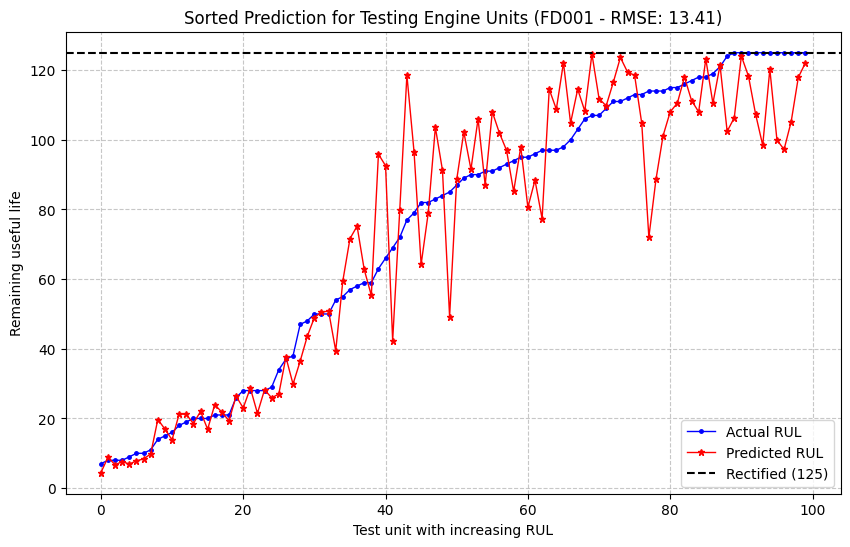


Evaluating FD002...


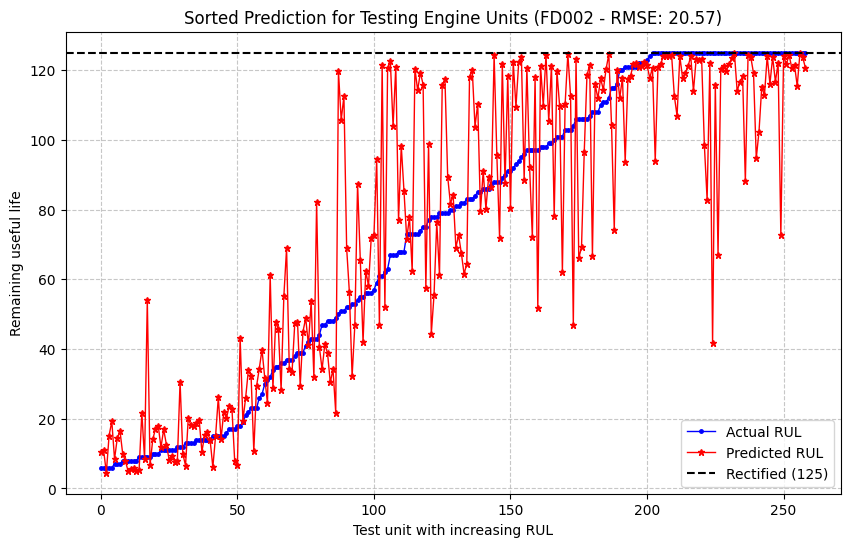


Evaluating FD003...


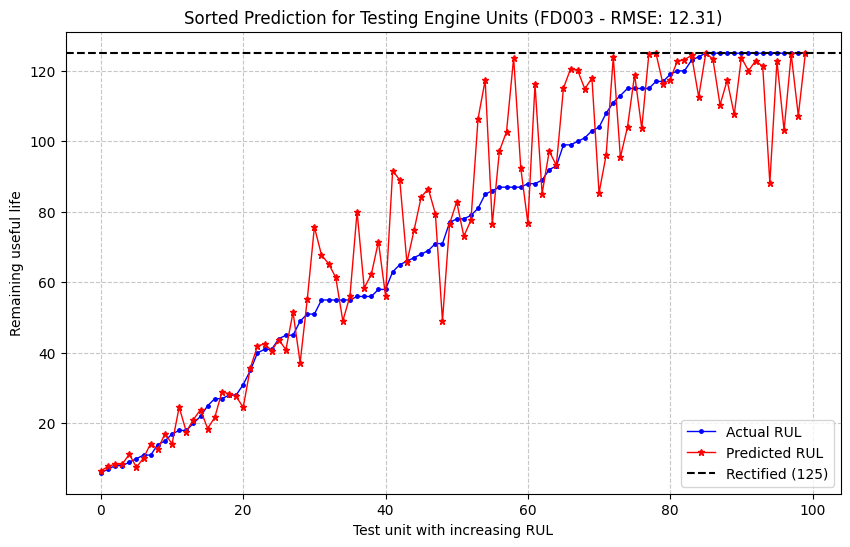


Evaluating FD004...


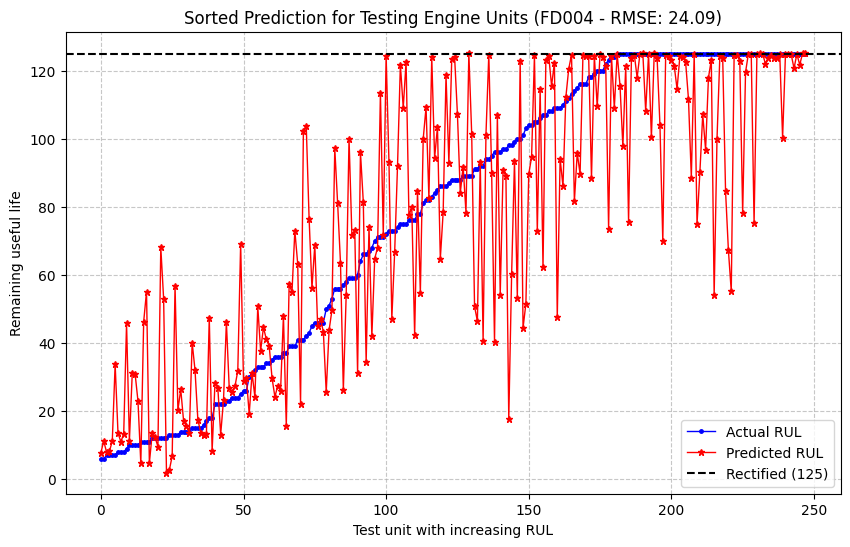

In [7]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def evaluate_model(dataset_id='FD001'):
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nEvaluating {dataset_id}...")

    checkpoint = torch.load(f'lstm_model_{dataset_id}.pth', map_location=DEVICE)
    model = LSTMModel(checkpoint['input_size'], checkpoint['hidden_size'], checkpoint['num_layers']).to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    test_df = pd.read_csv(f'test_preprocessed_{dataset_id}.csv')
    window_size = checkpoint['window_size']
    X_test, y_test = [], []

    for unit in test_df['unit'].unique():
        unit_data = test_df[test_df['unit'] == unit]
        features = unit_data.drop(columns=['unit', 'RUL']).values
        if len(unit_data) >= window_size:
            window = features[-window_size:]
        else:
            padding = np.zeros((window_size - len(unit_data), checkpoint['input_size']))
            window = np.vstack((padding, features))
        X_test.append(window)
        y_test.append(unit_data['RUL'].iloc[-1])

    X_test = torch.tensor(np.array(X_test), dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        preds = model(X_test).cpu().numpy().flatten()

    from sklearn.metrics import mean_squared_error
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    # Sort results by true RUL for a better visualization (matches paper format)
    y_test = np.array(y_test)
    sort_idx = np.argsort(y_test)
    sorted_y_test = y_test[sort_idx]
    sorted_preds = preds[sort_idx]

    plt.figure(figsize=(10, 6))
    plt.plot(sorted_y_test, color='blue', label='Actual RUL', marker='.', markersize=5, linewidth=1)
    plt.plot(sorted_preds, color='red', label='Predicted RUL', marker='*', markersize=5, linewidth=1)
    plt.axhline(y=125, color='black', linestyle='--', label='Rectified (125)')
    plt.title(f'Sorted Prediction for Testing Engine Units ({dataset_id} - RMSE: {rmse:.2f})')
    plt.xlabel('Test unit with increasing RUL')
    plt.ylabel('Remaining useful life')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

for ds in ['FD001', 'FD002', 'FD003', 'FD004']:
    evaluate_model(ds)